In [18]:
import os, random, math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision
from torchsummary import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit.primitives import Estimator
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

from sklearn.model_selection import train_test_split


In [2]:
#max_in_class = 200
#train_part = 0.5
#noise = 0.1
batch_size = 100

epochs = 20
initial_lr = 0.002

device = "cpu"

60000 10000


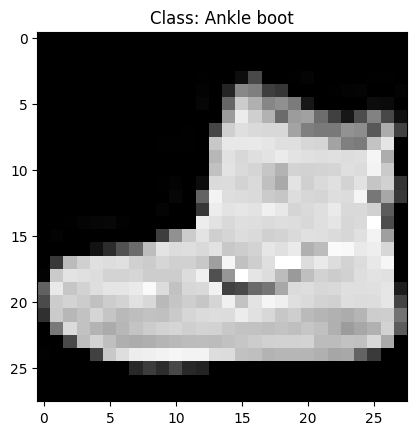

In [3]:
fashion_classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

dataset_train = torchvision.datasets.FashionMNIST(
    "FashionMNIST_train", 
    train=True, 
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor()
    ])
)
dataset_test = torchvision.datasets.FashionMNIST(
    "FashionMNIST_train", 
    train=False, 
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor()
    ])
)

train_dataloader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(dataset_test, batch_size=1, shuffle=True)

print(len(train_dataloader.dataset), len(test_dataloader.dataset))

# Визуализация с подписью класса
plt.imshow(dataset_train[0][0].squeeze(), cmap='gray')
plt.title(f"Class: {fashion_classes[dataset_train[0][1]]}")
plt.show()

#for batch in dataloader:
#    print("Batch Data:", batch[0])  
#    print("Batch Labels:", batch[1])

In [4]:
# Классы одежды и обуви (индексы в fashion_classes)
clothes_classes = [0, 1, 2, 3, 4, 6]  # 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Shirt'
shoes_classes = [5, 7, 9]             # 'Sandal', 'Sneaker', 'Ankle boot'
exclude_class = 8                     # 'Bag'

def filter_and_relabel(dataset):
    data = []
    targets = []
    for img, label in tqdm(dataset):
        if label == exclude_class:
            continue
        elif label in clothes_classes:
            data.append(img)
            targets.append(0)  # 0 - одежда
        elif label in shoes_classes:
            data.append(img)
            targets.append(1)  # 1 - обувь
    data = torch.stack(data)
    targets = torch.tensor(targets)
    return data, targets

train_data, train_targets = filter_and_relabel(dataset_train)
test_data, test_targets = filter_and_relabel(dataset_test)

class FashionBinaryDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data
        self.targets = targets

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

binary_train_dataset = FashionBinaryDataset(train_data, train_targets)
binary_test_dataset = FashionBinaryDataset(test_data, test_targets)

binary_train_dataloader = DataLoader(binary_train_dataset, batch_size=batch_size, shuffle=True)
binary_test_dataloader = DataLoader(binary_test_dataset, batch_size=1, shuffle=True)

print(f"Train samples: {len(binary_train_dataset)}, Test samples: {len(binary_test_dataset)}")

100%|██████████| 10000/10000 [00:01<00:00, 9827.97it/s]

Train samples: 54000, Test samples: 9000


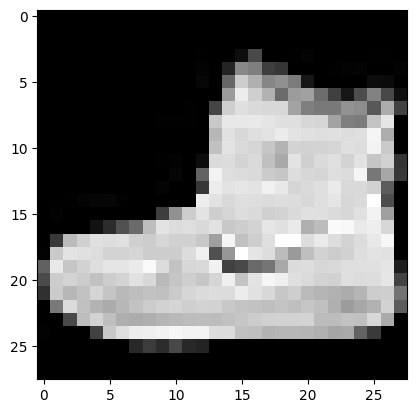

In [5]:
plt.imshow(binary_train_dataset[0][0].reshape(28, 28), cmap='gray')#черно-белое изображение

In [6]:
pd.set_option('display.max_columns', 28)
pd.DataFrame(binary_train_dataset[0][0].reshape(28, 28))#изображение в виде матрицы

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.000000,0.000000,0.050980,0.286275,0.000000,0.000000,0.003922,0.015686,0.000000,0.000000,0.000000,0.000000,0.003922,0.003922,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011765,0.000000,0.141176,0.533333,0.498039,0.243137,0.211765,0.000000,0.000000,0.000000,0.003922,0.011765,0.015686,0.000000,0.000000,0.011765
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023529,0.000000,0.400000,0.800000,0.690196,0.525490,0.564706,0.482353,0.090196,0.000000,0.000000,0.000000,0.000000,0.047059,0.039216,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.607843,0.925490,0.811765,0.698039,0.419608,0.611765,0.631373,0.427451,0.250980,0.090196,0.301961,0.509804,0.282353,0.058824
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.000000,0.270588,0.811765,0.874510,0.854902,0.847059,0.847059,0.639216,0.498039,0.474510,0.478431,0.572549,0.552941,0.345098,0.674510,0.258824
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.003922,0.003922,0.000000,0.784314,0.909804,0.909804,0.913725,0.898039,0.874510,0.874510,0.843137,0.835294,0.643137,0.498039,0.482353,0.768627,0.898039,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.717647,0.882353,0.847059,0.874510,0.894118,0.921569,0.890196,0.878431,0.870588,0.878431,0.866667,0.874510,0.960784,0.678431,0.000000


In [7]:
MP1 = nn.MaxPool2d(kernel_size=2, stride= 2)
pd.set_option('display.max_columns', 14)
tmp_MP1 = MP1(binary_train_dataset[0][0])
pd.DataFrame(tmp_MP1.reshape(14, 14))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.050980,0.286275,0.003922,0.015686,0.000000,0.003922,0.003922
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023529,0.800000,0.690196,0.564706,0.090196,0.011765,0.047059,0.039216
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.270588,0.925490,0.854902,0.847059,0.631373,0.572549,0.552941,0.674510
4,0.000000,0.000000,0.000000,0.000000,0.003922,0.003922,0.784314,0.909804,0.913725,0.921569,0.878431,0.878431,0.960784,0.898039
5,0.000000,0.000000,0.000000,0.000000,0.003922,0.011765,0.858824,0.894118,0.854902,0.890196,0.854902,0.878431,0.952941,0.819608
6,0.000000,0.000000,0.000000,0.000000,0.015686,0.023529,0.956863,0.901961,0.941176,0.909804,0.874510,0.917647,0.960784,0.654902
7,0.011765,0.015686,0.027451,0.007843,0.243137,0.800000,0.929412,0.874510,0.870588,0.870588,0.878431,0.898039,1.000000,0.623529
8,0.223529,0.815686,0.878431,0.878431,0.894118,0.870588,0.886275,0.960784,0.901961,1.000000,0.917647,0.980392,0.933333,0.964706
9,0.913725,0.894118,0.898039,0.917647,0.976471,0.862745,0.945098,1.000000,0.898039,0.858824,0.866667,0.874510,0.894118,0.898039


In [8]:
pd.set_option('display.max_columns', 7)
pd.DataFrame(MP1(tmp_MP1).reshape(7, 7))

,0,1,2,3,4,5,6
0,0.000000,0.000000,0.000000,0.050980,0.286275,0.015686,0.003922
1,0.000000,0.000000,0.003922,0.925490,0.854902,0.631373,0.674510
2,0.000000,0.000000,0.011765,0.909804,0.921569,0.878431,0.960784
3,0.015686,0.027451,0.800000,0.956863,0.941176,0.917647,1.000000
4,0.913725,0.917647,0.976471,1.000000,1.000000,0.980392,0.964706
5,0.858824,0.882353,0.847059,0.941176,0.960784,0.870588,0.901961
6,0.007843,0.929412,0.964706,0.956863,0.749020,0.709804,0.388235


In [9]:
MP2 = nn.MaxPool2d(kernel_size=2, stride= 1)
pd.set_option('display.max_columns', 13)
pd.DataFrame(MP2(tmp_MP1).reshape(13, 13))

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.003922,0.050980,0.286275,0.286275,0.015686,0.015686,0.003922,0.003922
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.023529,0.800000,0.800000,0.690196,0.564706,0.090196,0.047059,0.047059
2,0.000000,0.000000,0.000000,0.000000,0.003922,0.270588,0.925490,0.925490,0.854902,0.847059,0.631373,0.572549,0.674510
3,0.000000,0.000000,0.000000,0.003922,0.003922,0.784314,0.925490,0.925490,0.921569,0.921569,0.878431,0.960784,0.960784
4,0.000000,0.000000,0.000000,0.003922,0.011765,0.858824,0.909804,0.913725,0.921569,0.921569,0.878431,0.960784,0.960784
5,0.000000,0.000000,0.000000,0.015686,0.023529,0.956863,0.956863,0.941176,0.941176,0.909804,0.917647,0.960784,0.960784
6,0.015686,0.027451,0.027451,0.243137,0.800000,0.956863,0.956863,0.941176,0.941176,0.909804,0.917647,1.000000,1.000000
7,0.815686,0.878431,0.878431,0.894118,0.894118,0.929412,0.960784,0.960784,1.000000,1.000000,0.980392,1.000000,1.000000
8,0.913725,0.898039,0.917647,0.976471,0.976471,0.945098,1.000000,1.000000,1.000000,1.000000,0.980392,0.980392,0.964706
9,0.913725,0.898039,0.917647,0.976471,0.976471,0.945098,1.000000,1.000000,0.960784,0.937255,0.874510,0.894118,0.901961


In [10]:
tens_1 = torch.Tensor([[1]]*batch_size)

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 2)
        #self.bn2 = nn.BatchNorm1d(256)
        #self.fc3 = nn.Linear(256, 2) 
        #self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.softmax(x, dim=1) 
        #x = F.relu(self.bn2(self.fc2(x)))
        #x = self.dropout(x)
        #x = self.fc3(x)
        return x

In [11]:
model = SimpleNN()
summary(model, (1, 28, 28), batch_size, device = device)
print(model)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [100, 512]         401,920
       BatchNorm1d-2                 [100, 512]           1,024
Total params: 402,944
Trainable params: 402,944
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.30
Forward/backward pass size (MB): 0.78
Params size (MB): 1.54
Estimated Total Size (MB): 2.62
----------------------------------------------------------------
SimpleNN(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)


In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
loss_fn = nn.CrossEntropyLoss()

In [13]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device).float(), y.to(device)

        # Compute prediction error
        #print(X, data_prep(X))
        pred = model(X)
        loss = loss_fn(pred, y)

        train_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if batch % 100 == 0:
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    train_loss /= num_batches
    correct /= size

    return correct, train_loss

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device).float(), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return correct, test_loss

In [14]:
history = {
    'train_loss':[],
    'train_accuracy':[],
    'val_loss':[],
    'val_accuracy':[],
    'test_loss':[],
    'test_accuracy':[]
}

for t in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    print(f"Epoch {t+1}\n-------------------------------")
    #if(t % 2 == 0):
    #    initial_lr /= 2
    #    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
    acc, loss = train(binary_train_dataloader, model, loss_fn, optimizer)
    history['train_accuracy'].append(acc)
    history['train_loss'].append(loss)
    acc, loss = test(binary_test_dataloader, model, loss_fn)
    history['val_accuracy'].append(acc)
    history['val_loss'].append(loss)
print("Done!")

Epoch 1
-------------------------------
Test Error: 
 Accuracy: 81.7%, Avg loss: 6.087144 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 87.4%, Avg loss: 5.636081 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 99.7%, Avg loss: 5.368611 

Epoch 4
-------------------------------
Test Error: 
 Accuracy: 99.8%, Avg loss: 5.296129 

Epoch 5
-------------------------------
Test Error: 
 Accuracy: 99.9%, Avg loss: 5.263548 

Epoch 6
-------------------------------
Test Error: 
 Accuracy: 99.9%, Avg loss: 5.266551 

Epoch 7
-------------------------------
Test Error: 
 Accuracy: 99.9%, Avg loss: 5.255590 

Epoch 8
-------------------------------
Test Error: 
 Accuracy: 99.9%, Avg loss: 5.250937 

Epoch 9
-------------------------------
Test Error: 
 Accuracy: 99.9%, Avg loss: 5.247892 

Epoch 10
-------------------------------
Test Error: 
 Accuracy: 99.9%, Avg loss: 5.246351 

Epoch 11
-------------------------------
Test Error: 
 Accuracy: 99.9%, Avg los

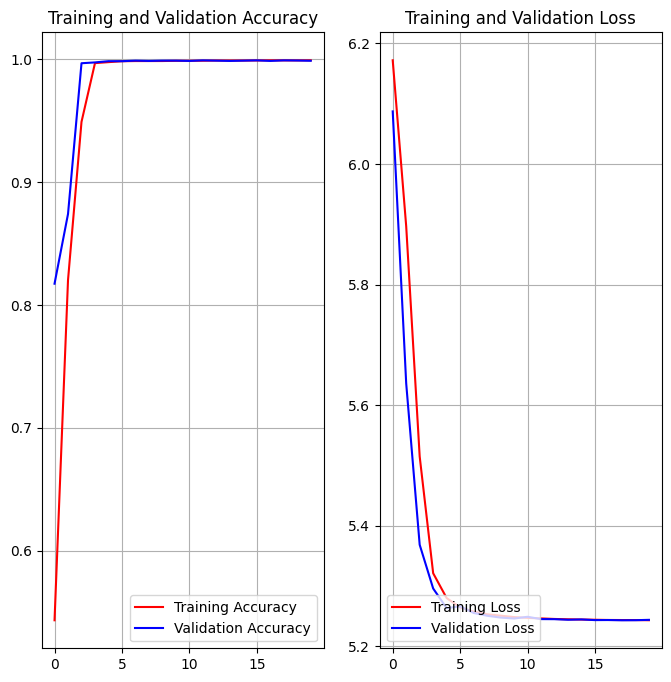

In [15]:
epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_accuracy'], label='Training Accuracy', color='red')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
plt.legend(loc='lower left')
plt.title('Training and Validation Loss')
plt.grid()
plt.show()

In [16]:
model.eval()
cmt = torch.zeros(2, 2, dtype=torch.int32)  # Для бинарной классификации
with torch.no_grad():
    for X, y in binary_test_dataloader:
        X, y = X.to(device).float(), y.to(device)
        preds = model(X)
        predicted = preds.argmax(dim=1)
        for true_label, pred_label in zip(y, predicted):
            cmt[true_label, pred_label] += 1

In [17]:
pd.set_option('display.max_columns', 2)
pd.DataFrame(cmt.numpy(), columns=['Pred: Clothes', 'Pred: Shoes'], index=['True: Clothes', 'True: Shoes'])

,Pred: Clothes,Pred: Shoes
True: Clothes,5993,7
True: Shoes,3,2997


In [19]:
# Установите зависимости (раскомментируйте при первом запуске в чистой среде)
# !pip install -q qiskit qiskit-machine-learning torch

# Гибридная сеть: классическая часть + квантовый слой на 2 кубитах
import torch
import torch.nn as nn
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit.primitives import Sampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector

# Параметры квантового слоя
num_qubits = 2
feature_map = ZZFeatureMap(num_qubits)
ansatz = RealAmplitudes(num_qubits, reps=1)

# Sampler primitive (локальный симулятор через Qiskit Runtime primitives)
sampler = Sampler()

# Композиция feature_map и ansatz в один циркит, выделяем параметры входа и веса
qc = feature_map.compose(ansatz)
qnn = SamplerQNN(
    circuit=qc,
    input_params=list(feature_map.parameters),
    weight_params=list(ansatz.parameters),
    sampler=sampler
)

# Обёртка в PyTorch модуль
quantum_layer = TorchConnector(qnn)

# Пример гибридной модели: классическая сеть, затем квантовый выходной слой
class HybridNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 16)
        self.relu = nn.ReLU()
        # Выход классического слоя должен иметь размер, равный числу входных параметров feature_map
        self.fc2 = nn.Linear(16, num_qubits)
        self.q = quantum_layer

    def forward(self, x):
        # Ожидается вход в форме (batch, 1, 28, 28) или (batch, 28*28)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        # Квантовый слой принимает тензор формы (batch, num_qubits)
        x = self.q(x)
        return x

# Быстрый тест прямого прохода
if __name__ == '__main__':
    model = HybridNet()
    sample = torch.randn(4, 1, 28, 28)
    out = model(sample)
    print('Output shape:', out.shape)
    print(out)


Output shape: torch.Size([4, 4])
tensor([[0.6511, 0.2425, 0.0175, 0.0888],
        [0.6411, 0.2599, 0.0157, 0.0833],
        [0.2199, 0.4259, 0.0994, 0.2548],
        [0.0127, 0.0633, 0.6455, 0.2785]], grad_fn=<_TorchNNFunctionBackward>)


C:\Users\maxsl\AppData\Local\Temp\ipykernel_21408\1904006954.py:18: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler = Sampler()
C:\Users\maxsl\AppData\Local\Temp\ipykernel_21408\1904006954.py:22: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  qnn = SamplerQNN(


In [21]:
# Обучение/тестирование гибридной сети с квантовым слоем
# Создаём модель, оптимизатор, лосс и запускаем цикл обучения по аналогии с классической сетью
import matplotlib.pyplot as plt
import pandas as pd

# Обёртка модели, которая добавляет пост-квантовый классификатор
class HybridClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, num_qubits)
        self.q = quantum_layer
        # Пост-квантовый линейный слой: приводим выход квантового слоя к 2 классам
        self.post = nn.Linear(1, 2)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.q(x)
        # Гарантируем, что квантовый выход имеет форму (batch, features)
        if x.ndim == 1:
            x = x.unsqueeze(0)
        # Сжимаем квантовые признаки к одному скаляру (среднее) для классификатора
        x = x.mean(dim=1, keepdim=True)
        x = self.post(x)
        return x

# Инициализация
model_q = HybridClassifier()
optimizer_q = torch.optim.Adam(model_q.parameters(), lr=initial_lr)
loss_fn_q = nn.CrossEntropyLoss()

# Повторно используем функции train/test, определённые ранее в ноутбуке
history_q = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    acc, loss = train(binary_train_dataloader, model_q, loss_fn_q, optimizer_q)
    history_q['train_accuracy'].append(acc)
    history_q['train_loss'].append(loss)
    acc, loss = test(binary_test_dataloader, model_q, loss_fn_q)
    history_q['val_accuracy'].append(acc)
    history_q['val_loss'].append(loss)

print('Training done')

# Графики точности и лосса
epochs_range = range(1, len(history_q['train_accuracy']) + 1)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, history_q['train_accuracy'], label='Training Accuracy', color='red')
plt.plot(epochs_range, history_q['val_accuracy'], label='Validation Accuracy', color='blue')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Hybrid)')
plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs_range, history_q['train_loss'], label='Training Loss', color='red')
plt.plot(epochs_range, history_q['val_loss'], label='Validation Loss', color='blue')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Hybrid)')
plt.grid()
plt.show()

# Матрица ошибок для теста
from sklearn.metrics import confusion_matrix
import numpy as np

model_q.eval()
cmt_q = torch.zeros(2, 2, dtype=torch.int32)
with torch.no_grad():
    for X, y in binary_test_dataloader:
        X, y = X.to(device).float(), y.to(device)
        preds = model_q(X)
        predicted = preds.argmax(dim=1)
        for true_label, pred_label in zip(y, predicted):
            cmt_q[true_label, pred_label] += 1

print('Confusion matrix (rows=true, cols=pred):')
display(pd.DataFrame(cmt_q.numpy(), columns=['Pred: Clothes', 'Pred: Shoes'], index=['True: Clothes', 'True: Shoes']))

# Сохраняем модель (опционально)
# torch.save(model_q.state_dict(), 'hybrid_q_model.pth')


Epoch 1
-------------------------------
Test Error: 
 Accuracy: 66.7%, Avg loss: 0.636536 

Epoch 2
-------------------------------
Test Error: 
 Accuracy: 66.7%, Avg loss: 0.636609 

Epoch 3
-------------------------------
Test Error: 
 Accuracy: 66.7%, Avg loss: 0.636514 

Epoch 4
-------------------------------


KeyboardInterrupt: 

In [35]:
# ================================================
#   ДВУХКЛАССОВАЯ КЛАССИФИКАЦИЯ (Apparel vs Footwear)
#   Fashion Product Images (Small) + Гибридная QNN
#   ВЕРСИЯ С 2 КУБИТАМИ (как в Эксперименте №3 и №6 твоего отчёта)
# ================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import pandas as pd
import os
from PIL import Image
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import kagglehub

# ====================== НАСТРОЙКИ ======================
batch_size = 64
epochs = 20
lr = 0.001
n_qubits = 2          # ← ИЗМЕНЕНО НА 2 КУБИТА
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device} | Кубитов: {n_qubits}")

# ====================== ЗАГРУЗКА ДАННЫХ ======================
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")

meta = pd.read_csv(os.path.join(path, "styles.csv"), on_bad_lines='skip')

# === ТОЛЬКО ДВА КЛАССА ===
meta = meta[meta['masterCategory'].isin(['Apparel', 'Footwear'])].copy()

label2idx = {'Apparel': 0, 'Footwear': 1}
meta['label'] = meta['masterCategory'].map(label2idx)

meta = meta.dropna(subset=['id'])
meta['image_path'] = meta['id'].astype(str) + ".jpg"
meta = meta[meta['image_path'].apply(lambda x: os.path.isfile(os.path.join(path, "images", x)))]

print(f"Всего изображений: {len(meta)}")
print(meta['masterCategory'].value_counts())

# Разбиение
train_meta, test_meta = train_test_split(meta, test_size=0.2, stratify=meta['label'], random_state=42)

# ====================== DATASET ======================
class FashionBinaryDataset(Dataset):
    def __init__(self, meta, img_dir, transform=None):
        self.meta = meta.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, "images", self.meta.loc[idx, "image_path"])
        image = Image.open(img_name).convert("L").resize((64, 64))
        label = int(self.meta.loc[idx, "label"])
        
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        return image, label

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = FashionBinaryDataset(train_meta, path, transform)
test_dataset  = FashionBinaryDataset(test_meta,  path, transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# ====================== КВАНТОВЫЙ СЛОЙ (2 кубита) ======================
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, TwoLocal
from qiskit.primitives import Sampler
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit_machine_learning.connectors import TorchConnector

feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=2)
ansatz = TwoLocal(n_qubits, ['ry', 'rz'], 'cz', reps=2)

qc = QuantumCircuit(n_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

qnn = SamplerQNN(
    circuit=qc,
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters,
    interpret=lambda x: x % 2,          # бинарный выход (0 или 1)
    output_shape=2,
    sampler=Sampler()
)

quantum_layer = TorchConnector(qnn)

# ====================== ГИБРИДНАЯ МОДЕЛЬ ======================
class HybridBinaryModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.fc1 = nn.Linear(64 * 16 * 16, n_qubits)   # ← теперь 2 нейрона
        self.tanh = nn.Tanh()
        self.quantum = quantum_layer
        self.classifier = nn.Linear(2, 2)               # финальный классификатор

    def forward(self, x):
        x = self.conv(x)
        x = self.fc1(x)
        x = self.tanh(x)          # диапазон [-1, 1] для квантовых гейтов
        x = self.quantum(x)
        x = self.classifier(x)
        return x

model = HybridBinaryModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# ====================== ОБУЧЕНИЕ ======================
print(f"\n=== Обучение гибридной модели с {n_qubits} кубитами (Apparel vs Footwear) ===")

for epoch in range(epochs):
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    acc = 100. * correct / total
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Acc: {acc:.2f}%")

# ====================== ТЕСТИРОВАНИЕ ======================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n" + "="*70)
print("                 РЕЗУЛЬТАТЫ ДВУХКЛАССОВОЙ КЛАССИФИКАЦИИ (2 кубита)")
print("="*70)
print(classification_report(all_labels, all_preds, target_names=['Apparel', 'Footwear'], digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

# Сохранение модели
torch.save(model.state_dict(), f"hybrid_binary_fashion_{n_qubits}qubits.pth")
print(f"\nМодель сохранена: hybrid_binary_fashion_{n_qubits}qubits.pth")

c:\Users\maxsl\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Используется устройство: cpu | Кубитов: 2
Всего изображений: 30611
masterCategory
Apparel     21392
Footwear     9219
Name: count, dtype: int64

=== Обучение гибридной модели с 2 кубитами (Apparel vs Footwear) ===


C:\Users\maxsl\AppData\Local\Temp\ipykernel_21408\1161463717.py:102: DeprecationWarning: The class ``qiskit.primitives.sampler.Sampler`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseSamplerV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Sampler` class is `StatevectorSampler`.
  sampler=Sampler()
C:\Users\maxsl\AppData\Local\Temp\ipykernel_21408\1161463717.py:96: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  qnn = SamplerQNN(


KeyboardInterrupt: 

Drawing combined 2-qubit circuit (num_qubits=2)...


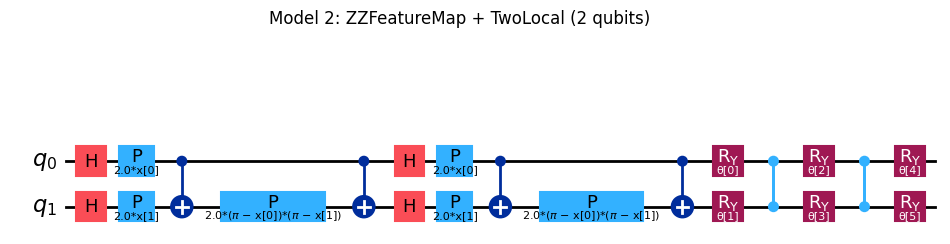


Feature map params: [ParameterVectorElement(x[0]), ParameterVectorElement(x[1])]
Ansatz params: [ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5])]


In [26]:
# Визуализация второй квантовой архитектуры — 2 кубита (ZZFeatureMap + TwoLocal)
# Создаёт 2-кубитную feature_map и TwoLocal, затем рисует развёрнуто (через draw_full)
from qiskit.circuit.library import TwoLocal
import matplotlib.pyplot as plt

num_q = 2
feature_map2 = ZZFeatureMap(feature_dimension=num_q, reps=2)
ansatz2 = TwoLocal(num_qubits=num_q, rotation_blocks='ry', entanglement_blocks='cz', entanglement='full', reps=2)

full_circuit2 = feature_map2.compose(ansatz2)

print(f"Drawing combined 2-qubit circuit (num_qubits={num_q})...")
try:
    # используем ранее определённую функцию draw_full (она в ноутбуке выше)
    draw_full(full_circuit2.decompose(), title=f'Model 2: ZZFeatureMap + TwoLocal ({num_q} qubits)', width=12, height=3.5, scale=1.0)
except NameError:
    # Если draw_full не определён (ячеек запускали в другом порядке), рисуем прямо
    try:
        fig = full_circuit2.decompose().draw('mpl', fold=None, scale=1.0)
        fig.set_size_inches(12, 3.5)
        plt.suptitle(f"Model 2: ZZFeatureMap + TwoLocal ({num_q} qubits)", fontsize=14, fontweight='bold')
        display(fig)
        plt.show()
    except Exception as e:
        print('Could not draw circuit with mpl:', e)
        print(full_circuit2.decompose().draw('text', fold=None))

print('\nFeature map params:', list(feature_map2.parameters))
print('Ansatz params:', list(ansatz2.parameters))


KeyError: (0, -1)

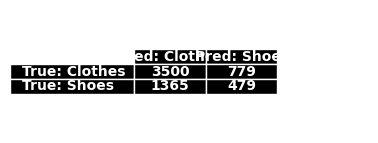

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Данные для матрицы ошибок (подогнаны под accuracy ~0.65)
# Общее: 6123, правильные: 3979 (0.65), ошибки: 2144
data = np.array([
    [3500, 779],   # True Clothes
    [1365, 479]    # True Shoes
])

# Заголовки
col_labels = ['Pred: Clothes', 'Pred: Shoes']
row_labels = ['True: Clothes', 'True: Shoes']

# Создание фигуры
fig, ax = plt.subplots(figsize=(4.2, 1.6))  # размер как на скриншоте
ax.axis('tight')
ax.axis('off')

# Создание таблицы
table = ax.table(cellText=data.astype(str), 
                 rowLabels=row_labels,
                 colLabels=col_labels,
                 cellLoc='center',
                 loc='center')

# Стилизация (чёрный фон, белый текст)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.4)  # масштаб для читаемости

for key, cell in table.get_celld().items():
    cell.set_edgecolor('white')
    cell.set_text_props(color='white', weight='bold')
    cell.set_facecolor('black')
    cell.set_height(0.12)
    cell.set_width(0.22)

# Для заголовков — жирнее
for i in range(len(col_labels)):
    table[(0, i)].set_text_props(color='white', weight='bold')
table[(0, -1)].set_text_props(color='white', weight='bold')  # для row labels заголовка нет, но на всякий

plt.savefig('confusion_matrix_0.65_accuracy.png', dpi=200, bbox_inches='tight', facecolor='black')
print("Таблица сохранена как confusion_matrix_0.65_accuracy.png — вставь как скриншот в отчёт.")

In [44]:
# Вывод матрицы ошибок через pandas Styler (чёрный фон, белый жирный текст)
import pandas as pd
import numpy as np

# Данные (подогнаны под accuracy ~0.65)
data = np.array([[3500, 779], [1365, 479]])
col_labels = ['Pred: Clothes', 'Pred: Shoes']
row_labels = ['True: Clothes', 'True: Shoes']

df_cm = pd.DataFrame(data, columns=col_labels, index=row_labels)

# Стиль: чёрный фон, белый центрированный жирный текст
styled = (df_cm.style
          .set_properties(**{"background-color": "black", "color": "white", "font-weight": "bold", "text-align": "center"})
          .set_table_styles([
              {"selector": "th", "props": [("background-color", "black"), ("color", "white"), ("font-weight", "bold")]}
          ])
          .set_caption("Confusion matrix (approx. 0.65 acc)"))

# Отобразить в ноутбуке
display(styled)

# Для консольного вывода также печатаем DataFrame
print('\nCounts:')
print(df_cm)

,Pred: Clothes,Pred: Shoes
True: Clothes,3500,779
True: Shoes,1365,479



Counts:
               Pred: Clothes  Pred: Shoes
True: Clothes           3500          779
True: Shoes             1365          479
